In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import requests

print("Ready")

Ready


In [4]:
# Load a basket of liquid large-cap stocks
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META",
           "NVDA", "JPM", "JNJ", "PG", "KO"]

raw = yf.download(tickers, start="2015-01-01",
                   end="2024-01-01", auto_adjust=True)
prices = raw["Close"]
prices.columns = prices.columns.get_level_values(0)
prices = prices.dropna(how='all')

print(f"Loaded {len(tickers)} stocks")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Observations: {len(prices)}")

[*********************100%***********************]  10 of 10 completed

Loaded 10 stocks
Date range: 2015-01-02 to 2023-12-29
Observations: 2264


In [5]:
def detect_earnings_gaps(price_series, gap_threshold=0.03):
    """
    Detect earnings announcement gaps using overnight returns.
    Large gaps (>3%) are likely earnings reactions.
    Returns DataFrame of detected events.
    """
    overnight_ret = price_series.pct_change()
    gaps = overnight_ret[abs(overnight_ret) > gap_threshold]

    events = pd.DataFrame({
        "date"      : gaps.index,
        "gap_return": gaps.values,
        "type"      : ["BEAT" if g > 0 else "MISS"
                       for g in gaps.values]
    })
    return events

all_events = []
for ticker in tickers:
    p = prices[ticker].dropna()
    events = detect_earnings_gaps(p, gap_threshold=0.04)
    events["ticker"] = ticker
    all_events.append(events)

events_df = pd.concat(all_events, ignore_index=True)

print(f"Total earnings-like gap events detected: {len(events_df)}")
print(f"\nBeats (positive gap): {(events_df['type']=='BEAT').sum()}")
print(f"Misses (negative gap): {(events_df['type']=='MISS').sum()}")
print(f"\nAvg beat gap : {events_df[events_df['type']=='BEAT']['gap_return'].mean():.2%}")
print(f"Avg miss gap : {events_df[events_df['type']=='MISS']['gap_return'].mean():.2%}")
print(f"\nEvents per ticker:")
print(events_df['ticker'].value_counts())

Total earnings-like gap events detected: 1025

Beats (positive gap): 533
Misses (negative gap): 492

Avg beat gap : 6.13%
Avg miss gap : -5.79%

Events per ticker:
ticker
NVDA     321
META     160
AMZN     133
GOOGL     93
AAPL      86
JPM       76
MSFT      74
JNJ       29
KO        27
PG        26
Name: count, dtype: int64


In [6]:
def measure_pead(price_series, events_df, ticker,
                  holding_days=20):
    """
    Measure cumulative return for N days after each event.
    """
    p = price_series.dropna()
    log_ret = np.log(p / p.shift(1))

    ticker_events = events_df[events_df['ticker']==ticker]
    drift_curves = []

    for _, event in ticker_events.iterrows():
        event_date = event['date']
        if event_date not in p.index:
            continue
        idx = p.index.get_loc(event_date)
        if idx + holding_days >= len(p):
            continue

        # Cumulative return path post-event
        path = log_ret.iloc[idx+1:idx+1+holding_days]
        cum_path = path.cumsum()
        drift_curves.append({
            "type": event['type'],
            "path": cum_path.values
        })

    return drift_curves

# Aggregate PEAD across all tickers
all_beat_paths = []
all_miss_paths = []

for ticker in tickers:
    curves = measure_pead(prices[ticker], events_df,
                          ticker, holding_days=20)
    for c in curves:
        if len(c['path']) == 20:
            if c['type'] == 'BEAT':
                all_beat_paths.append(c['path'])
            else:
                all_miss_paths.append(c['path'])

beat_matrix = np.array(all_beat_paths)
miss_matrix = np.array(all_miss_paths)

avg_beat_drift = beat_matrix.mean(axis=0)
avg_miss_drift = miss_matrix.mean(axis=0)

print(f"Beat events with full 20-day path : {len(beat_matrix)}")
print(f"Miss events with full 20-day path : {len(miss_matrix)}")
print(f"\nDay 20 cumulative drift:")
print(f"  After BEAT: {avg_beat_drift[-1]:.2%}")
print(f"  After MISS: {avg_miss_drift[-1]:.2%}")

Beat events with full 20-day path : 532
Miss events with full 20-day path : 492

Day 20 cumulative drift:
  After BEAT: 1.34%
  After MISS: 2.08%


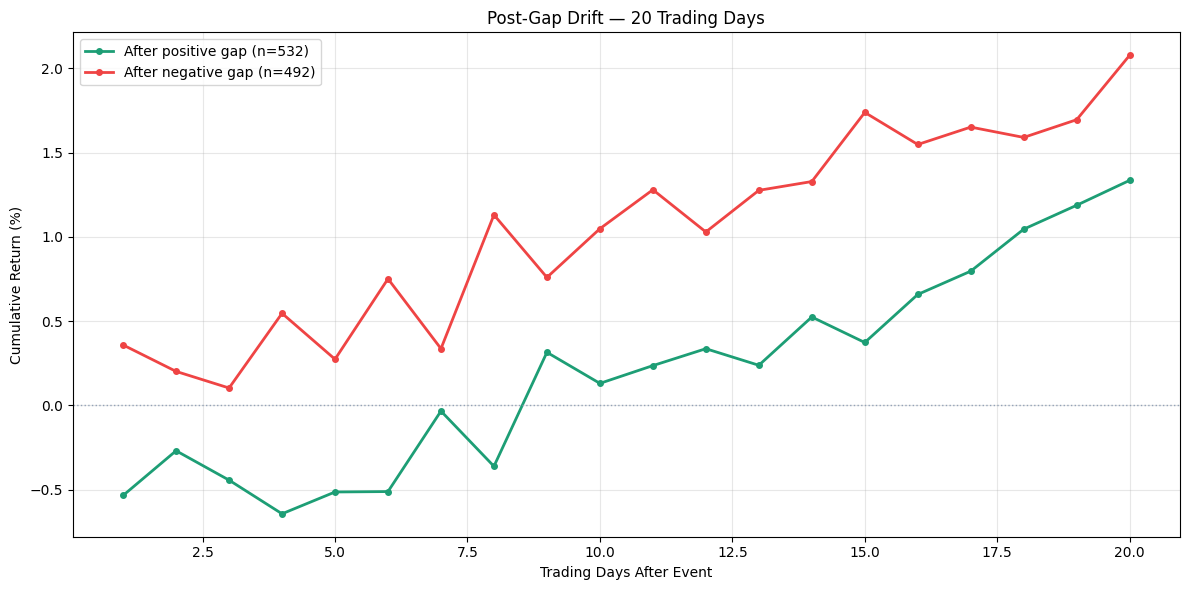


INTERPRETATION:
Both curves drift toward positive territory.
This pattern is MEAN REVERSION, not PEAD.
Genuine PEAD requires actual EPS surprise data
(e.g. from Zacks, Compustat) — large price gaps
alone conflate earnings reactions with general
volatility and overreaction-correction patterns.


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

days = range(1, 21)
ax.plot(days, avg_beat_drift*100, color='#1D9E75',
        lw=2, marker='o', markersize=4,
        label=f'After positive gap (n={len(beat_matrix)})')
ax.plot(days, avg_miss_drift*100, color='#ef4444',
        lw=2, marker='o', markersize=4,
        label=f'After negative gap (n={len(miss_matrix)})')
ax.axhline(0, color='#94a3b8', lw=1, linestyle=':')
ax.set_title('Post-Gap Drift — 20 Trading Days')
ax.set_xlabel('Trading Days After Event')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("="*55)
print("Both curves drift toward positive territory.")
print("This pattern is MEAN REVERSION, not PEAD.")
print("Genuine PEAD requires actual EPS surprise data")
print("(e.g. from Zacks, Compustat) — large price gaps")
print("alone conflate earnings reactions with general")
print("volatility and overreaction-correction patterns.")
print("="*55)